In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load CSV file
sheet_id = "1tEf8J1kbGZEFTOkoYqIjsdE3PkqBA9bX4MdNfMoLhjQ"
tab_gid = "908803302"
full_url = f"https://docs.google.com/spreadsheets/d/{sheet_id}/export?format=csv&gid={tab_gid}"
df = pd.read_csv(full_url, skiprows=2)
df

,Model,Compression,Size (MB),BLEU,ROC_AUC,PR_AUC,ROC_AUC.1,PR_AUC.1,ROC_AUC.2,PR_AUC.2,ROC_AUC.3,PR_AUC.3
0,pythia-70M,Original,281.731840,0.41996,0.645490,0.60866,0.64906,0.61320,0.66505,0.62855,0.61867,0.56285
1,pythia-70M,8-bit,122.126910,0.41390,0.645250,0.60859,0.64803,0.61204,0.66492,0.62869,0.61855,0.56315
2,pythia-70M,4-bit,113.771070,0.39210,0.633570,0.60442,0.63208,0.60402,0.65657,0.62541,0.58659,0.54286
3,pythia-160M,Original,649.341190,0.42493,0.657010,0.61645,0.65590,0.61574,0.67443,0.63549,0.63949,0.58167
4,pythia-160M,8-bit,240.116640,0.42310,0.656575,0.61566,0.65523,0.61455,0.67410,0.63498,0.63815,0.58095
5,pythia-160M,4-bit,202.650480,0.40604,0.644996,0.61117,0.64187,0.60902,0.66678,0.63265,0.59686,0.55090
6,pythia-410M,Original,1621.430000,0.43509,0.674133,0.62689,0.67518,0.62664,0.68873,0.64419,0.67112,0.61244
7,pythia-410M,8-bit,509.700000,0.43612,0.673955,0.62687,0.67496,0.62672,0.68860,0.64400,0.67126,0.61226
8,pythia-410M,4-bit,376.750000,0.42411,0.656712,0.61908,0.65961,0.61924,0.67734,0.63884,0.60386,0.55770
9,pythia-1B,Original,4047.192000,0.44180,0.689923,0.63865,0.69074,0.63931,0.70291,0.65535,0.68342,0.63675


In [ ]:
def generate_graphs(taskPerformance, MIA_attack, MIA_score, i):
    model_order = ['pythia-1.4B', 'pythia-1B','pythia-410M','pythia-160M', 'pythia-70M']

    compression_order = ['Original', '8-bit', '4-bit']
    markers = {'Original': 'o', '8-bit': 's', '4-bit': '^'}
    colors = {'pythia-70M': 'red', 'pythia-160M': 'purple',
          'pythia-410M': 'blue', 'pythia-1B': 'orange',
          'pythia-1.4B': 'green'}

    # Create the optimized visualization
    plt.figure(figsize=(10, 6))

    # Plot each point with model-specific color and compression-specific marker
    for model in model_order:
        for compression in compression_order:
            subset = df[(df['Model'] == model) & (df['Compression'] == compression)]
            if not subset.empty:
                plt.scatter(subset[taskPerformance], subset[MIA_score],
                        c=colors[model],
                        marker=markers[compression],
                        s=120,
                        alpha=0.8,
                        edgecolors='w',
                        linewidths=1)

    # Create custom legends
    from matplotlib.lines import Line2D

    # Model legend (color-coded)
    model_legend_elements = [Line2D([0], [0], marker='o', color='w', label=model,
                            markerfacecolor=colors[model], markersize=10) 
                            for model in model_order]

    # Compression legend (marker-coded)
    compression_legend_elements = [Line2D([0], [0], marker=markers[comp], color='w', label=comp,
                                markerfacecolor='gray', markersize=10)
                                for comp in compression_order]

    # Add legends
    first_legend = plt.legend(handles=model_legend_elements, title='Model Size',
                            loc='upper left', bbox_to_anchor=(.01, 1))
    plt.gca().add_artist(first_legend)
    plt.legend(handles=compression_legend_elements, title='Compression',
            loc='upper left', bbox_to_anchor=(.01, 0.7))
    # Add proper regression line
    sns.regplot(x=taskPerformance, y=MIA_score, data=df,
                scatter=False, ci=95,
                line_kws={'color':'black', 'alpha':0.2, 'linestyle':'--', 'label':'Linear fit (95% CI)'})

    corr = df[taskPerformance].corr(df[MIA_score])
    # Add correlation annotation
    # Compute suitable location dynamically
    x_pos = min(df[taskPerformance]) + 0.8 * (max(df[taskPerformance]) - min(df[taskPerformance]))
    y_pos = max(df[MIA_score]) - 0.7 * (max(df[MIA_score]) - min(df[MIA_score]))

    plt.annotate(f'Pearson r = {corr:.3f}\np < 0.001', 
                xy=(x_pos, y_pos), xycoords='data',
                fontsize=10, bbox=dict(boxstyle='round', alpha=0.2))
    # Labels and title
    plt.title(f'Correlation between Task Performance and {MIA_attack} MIA ({MIA_score.split(".")[0]})', pad=20)
    plt.xlabel('Task Performance (BLEU score)')
    plt.ylabel(f'MIA Score ({MIA_score.split(".")[0]})')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'./output/RQ3.{i}.png', dpi=300)
    plt.show()

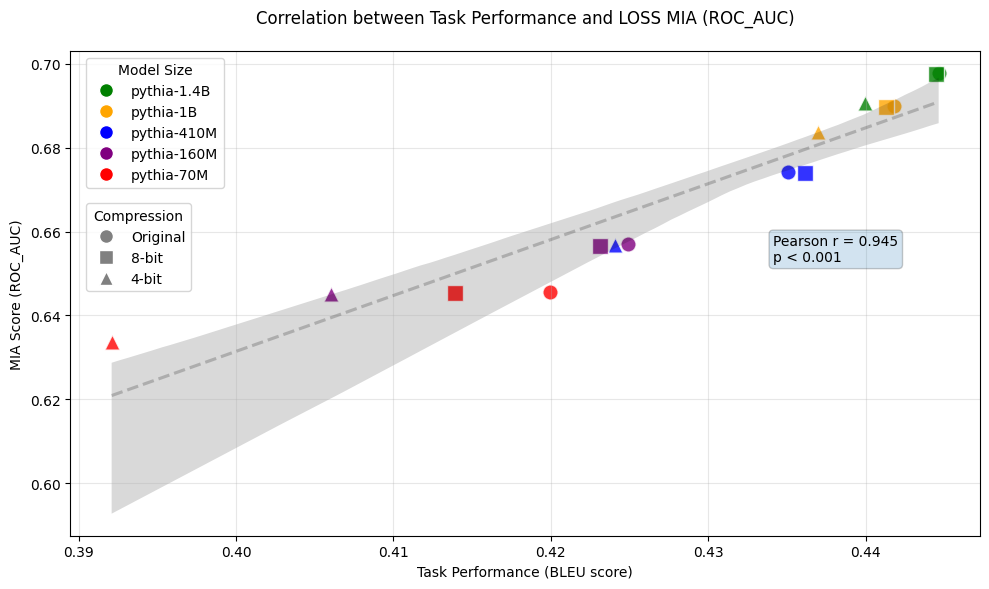

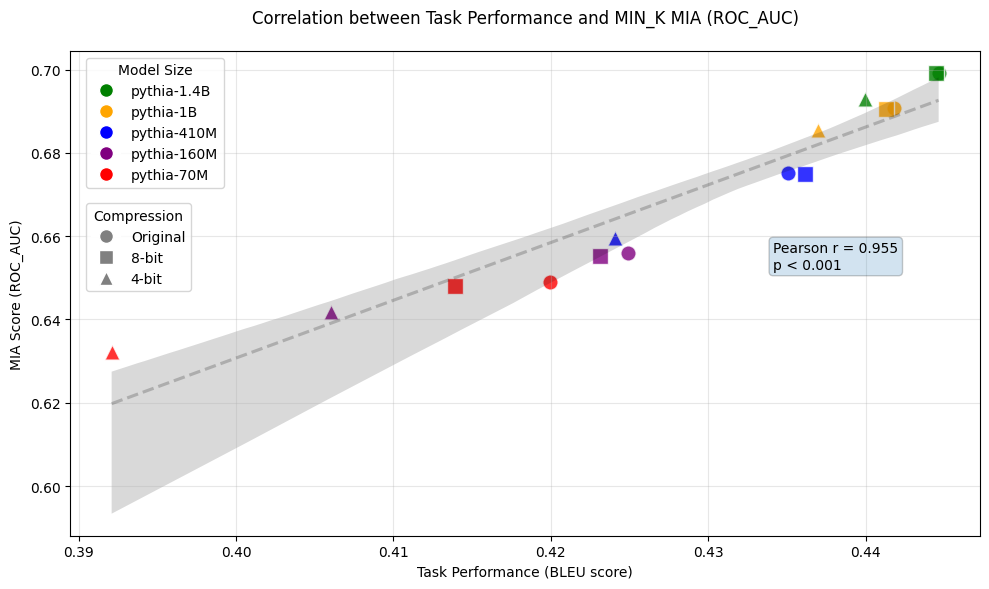

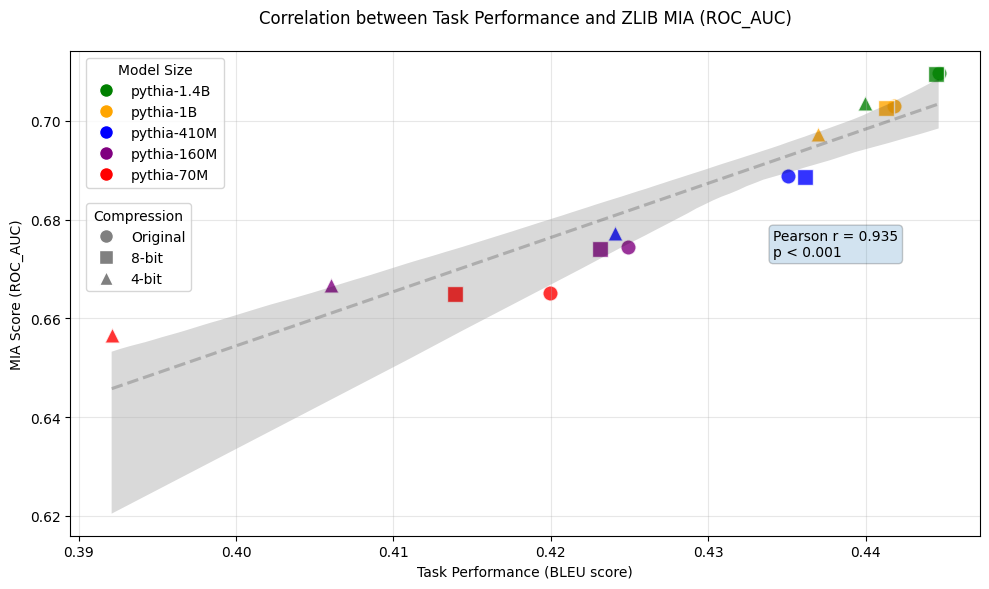

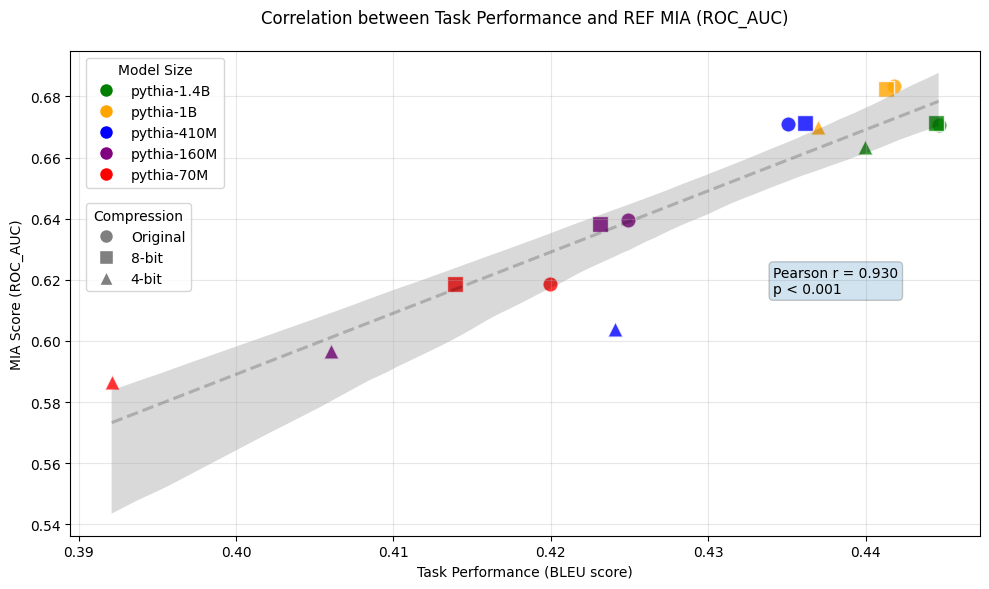

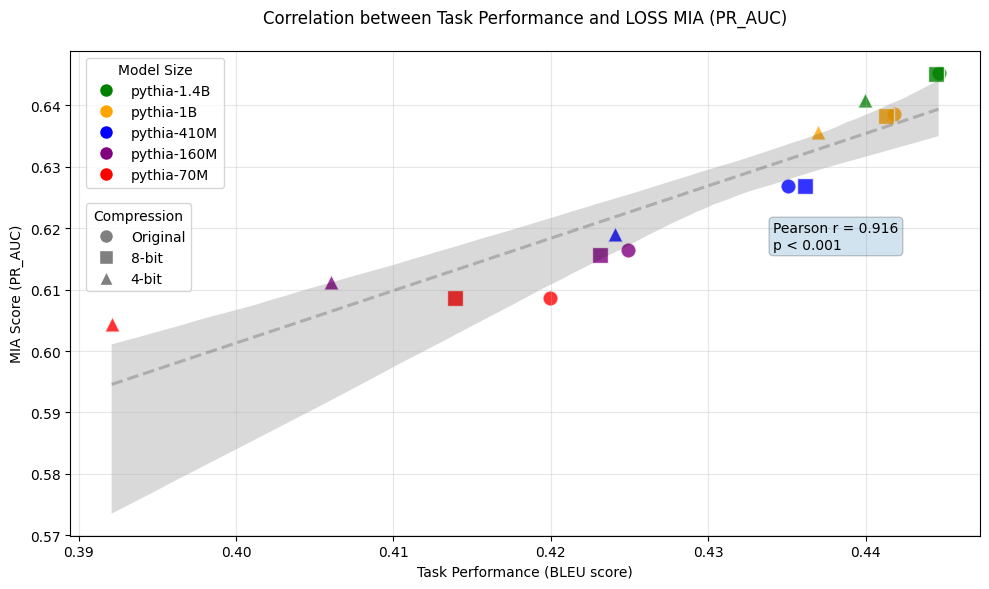

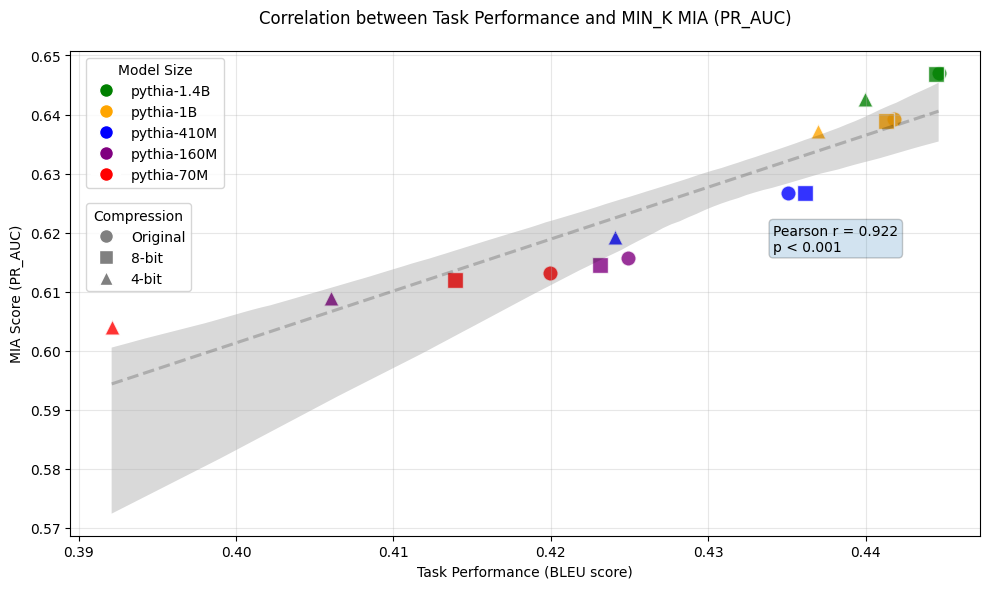

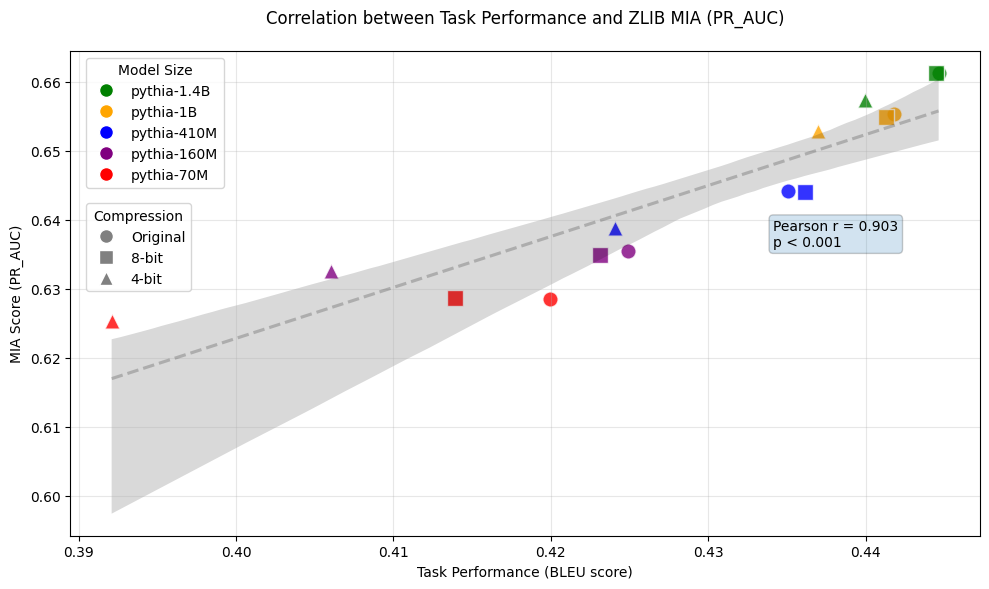

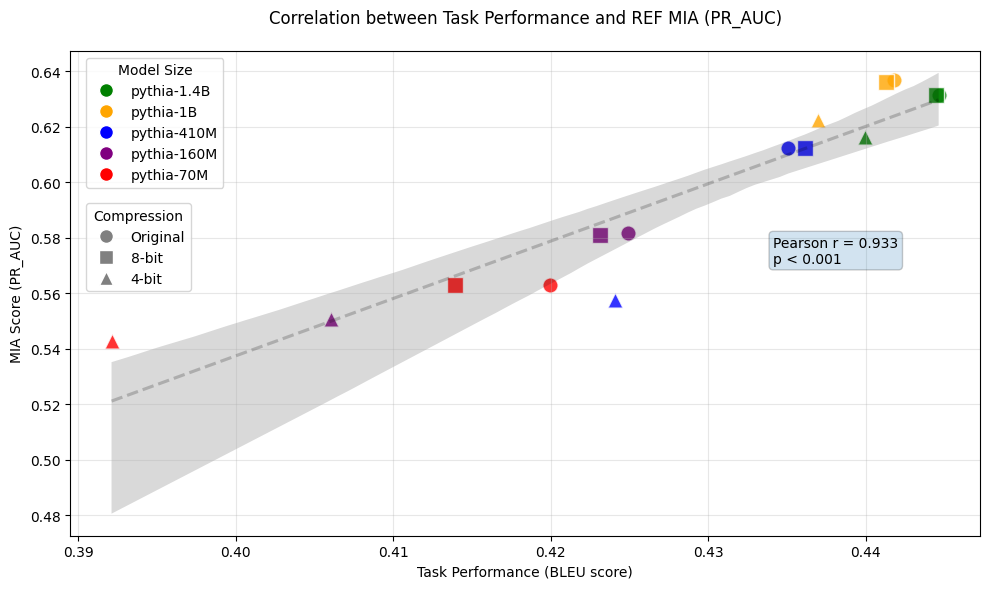

In [51]:
taskPerformance = "BLEU"
MIA_attacks = ["LOSS", "MIN_K", "ZLIB", "REF"]
MIA_scores = ["ROC_AUC", "ROC_AUC.1", "ROC_AUC.2", "ROC_AUC.3"]
for i, (MIA_attack, MIA_score) in enumerate(zip(MIA_attacks, MIA_scores), start=1):
    generate_graphs(taskPerformance, MIA_attack, MIA_score, i)


MIA_scores = ["PR_AUC", "PR_AUC.1", "PR_AUC.2", "PR_AUC.3"]
for i, (MIA_attack, MIA_score) in enumerate(zip(MIA_attacks, MIA_scores), start=5):
    generate_graphs(taskPerformance, MIA_attack, MIA_score, i)